# HF TDOA Analysis - Figures 11

This notebook uses the `hf_tdoa_lib` library to analyze HF TDOA measurements.

In [1]:
import os
import hf_tdoa_lib as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [2]:
base_dir   = 'data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [3]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)


Finding Chirps via Cross-Correlation
  Path Info:      PathInfo(TX: WA5FRF (EL09nn), RX: N5DUP (EM02ch), Range: 318.0 km, Band: 7 MHz)
  Template:       N6RFM_10Hz_per_ms_template.wav
  Sweep Rate:     10 Hz/ms
  Files to Process: 32
  Chirps per File: Top 10



Finding chirps: 100%|██████████| 32/32 [00:01<00:00, 19.06file/s, Chirps=10, Max Corr=4.84e+02]

✓ Completed chirp detection: 32 files processed, 320 total chirps found



## Find TDOAs

In [4]:
debug_TDOAs = False

# Find TDOAs for the default propagation mode using the simplified API
# The mode configurations (filter limits, search limits, model coefficients, and plotting params)
# are now stored in hf_tdoa_lib.MODE_CONFIGS

# Process the default mode (2F2-1F2)
chirps = tdoa.find_TDOAs(chirps, mode_string='2F2-1F2',
                        plot_fft=debug_TDOAs, only_one=debug_TDOAs)

# Build the TDOA configuration dictionary with model coefficients and plotting parameters
# Only include the 2F2-1F2 mode for this analysis
tdoa_dct = tdoa.build_tdoa_config(chirps, mode_strings=['2F2-1F2'])

# Print calculated model coefficients for verification
print("Calculated TDOA Model Coefficients:")
print("=" * 60)
for set_name, params in tdoa_dct.items():
    slope, intercept = params['model_coeffs']
    mode_str = params['mode_string']
    print(f"{set_name:12s} ({mode_str:8s}): slope={slope:6.1f}, intercept={intercept:6.1f}")
print("=" * 60)
print()


Processing Mode: 2F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     11.0 - 20.0 Hz
  Set Name:       2F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 32



Finding TDOAs (2F2-1F2): 100%|██████████| 32/32 [00:07<00:00,  4.37file/s, Mean TDOA=1.75 ms]


✓ Completed processing 2F2-1F2: 32 files processed

Calculated TDOA Model Coefficients:
2F2-1F2      (2F2-1F2 ): slope= 143.0, intercept=  33.0



## Layer Heights Comparison with Ionosonde

## Path Information

The `path_info` object provides convenient access to TX/RX coordinates and other path-related calculations.

In [5]:
# Access the path_info object stored when chirps were created
path_info = chirps.attrs['path_info']

# Display path information
print(f"Path Information:")
print(f"  {path_info}")
print()

# Get TX and RX coordinates from gridsquares
tx_lat, tx_lon = path_info.get_tx_latlon()
rx_lat, rx_lon = path_info.get_rx_latlon()
print(f"TX Location: {tx_lat:.3f}°N, {tx_lon:.3f}°E ({path_info.tx_grid})")
print(f"RX Location: {rx_lat:.3f}°N, {rx_lon:.3f}°E ({path_info.rx_grid})")
print()

# Calculate the great circle midpoint between TX and RX
mid_lat, mid_lon = path_info.get_midpoint()
print(f"Path Midpoint: {mid_lat:.3f}°N, {mid_lon:.3f}°E")
print()

# Calculate the azimuth from TX to RX
azimuth = path_info.get_path_azimuth()
print(f"Path Azimuth (TX→RX): {azimuth:.1f}°")

Path Information:
  PathInfo(TX: WA5FRF (EL09nn), RX: N5DUP (EM02ch), Range: 318.0 km, Band: 7 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 32.313°N, -99.792°E (EM02ch)

Path Midpoint: 30.938°N, -99.327°E

Path Azimuth (TX→RX): -15.7°


## Layer Heights with Solar Elevation and Eclipse Obscuration

The solar coordinates are automatically calculated from the TX/RX path midpoint.

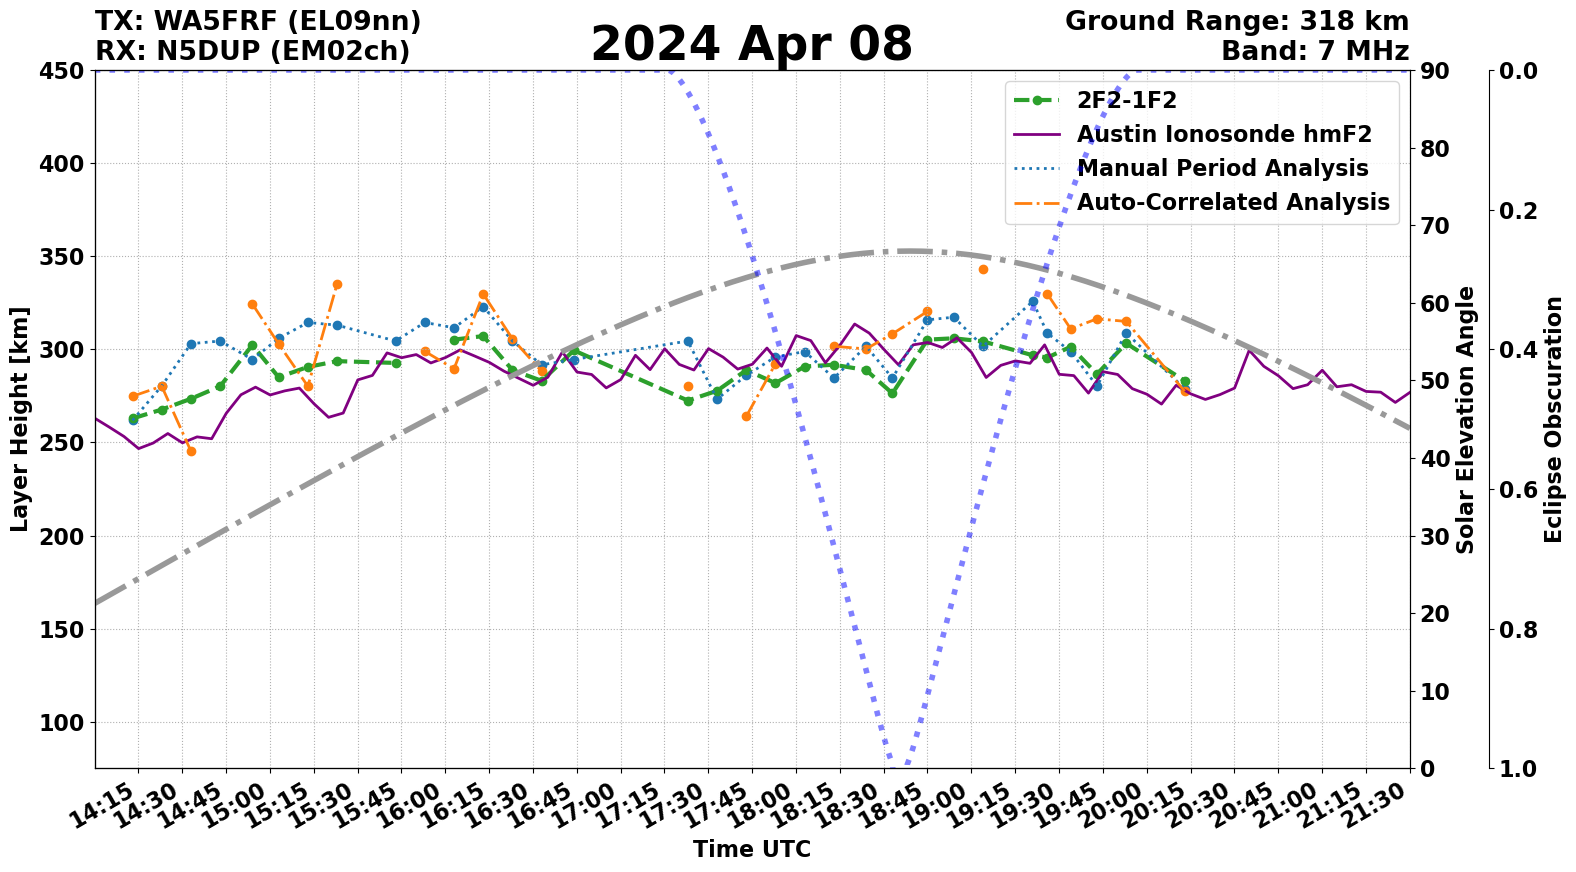

In [6]:
# Use the path midpoint for solar calculations
solar_lat, solar_lon = path_info.get_midpoint()

# Get the model coefficients for N5DUP (EM02ch grid square)
# From the OLD notebook, N5DUP uses slope=142, intercept=36.1
model_coeffs = (142, 36.1)

# Create enhanced plot with solar elevation, eclipse obscuration, and TDOA CSV overlays
tdoa.plot_hmf2(chirps, tdoa_dct,
               solar_lat=solar_lat,
               solar_lon=solar_lon,
               overlay_solar_elevation=True,
               overlay_eclipse=True,
               ionosonde_dct={'overlay_hmE': False},
               tdoa_csv_dct={
                   'csv_path': 'data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_TDOA.csv',
                   'model_coeffs': model_coeffs,
                   'overlay_manual': True,
                   'overlay_autocorr': True,
                   'manual_label': 'Manual Period Analysis',
                   'autocorr_label': 'Auto-Correlated Analysis'
               })